# 4. A two-level atom in a weakly driven cavity versus a classical dipole — SM Fig. S7

Atom and cavity resonant, laser detuned by $\Delta$ from both; $\kappa=\gamma$, $g=0.3\gamma$, weak drive. The emitter moves differ from the bosonic ones in exactly two ways (exclusion, and the sign of $\sigma^-\sigma^+=1-\sigma^+\sigma^-$). The atom and a harmonic dipole of the same rates transmit the same intensity; only the photon statistics distinguish them, and the diagrams reproduce the antibunching that exclusion produces.

**Part A** runs the calculation; **Part B** regenerates Fig. S7 with `make_figures.py atomcavity` (~1 min).

In [1]:
from common import *
FAST = True      # True: reduced orders and cutoffs, minutes.  False: the orders and cutoffs of the paper (see the runtime note)
print("repository:", os.path.basename(CODE), "| FAST =", FAST, "| paper sources:", "found" if PAPER else "not present (Tables V and SI from notebooks/paper_reference/)")

repository: gh_staging | FAST = True | paper sources: not present (Tables V and SI from notebooks/paper_reference/)


## Part A — the calculation

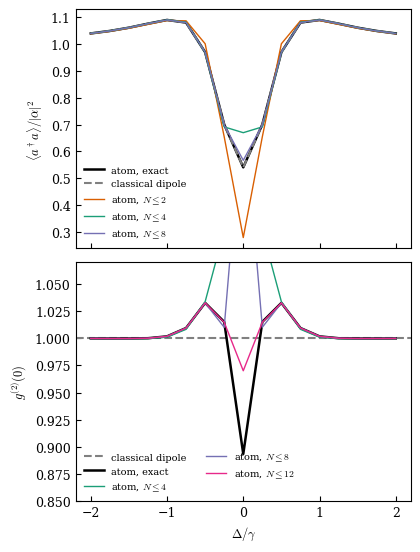

resonance: exact g2 0.89356, diagrams N<=12: 0.97003


In [2]:
from atom_cavity import series_cavity, exact_cavity
kap, gam_a, g_a, eta_a = 1.0, 1.0, 0.3, 0.02
Ds = np.linspace(-2,2,17 if FAST else 81); Nat = 12 if FAST else 32
obs = {"n": lambda a_,ad_: mul(ad_,a_), "n2": lambda a_,ad_: mul(mul(ad_,ad_),mul(a_,a_))}
exn,exg,pn,pg = [],[],[],[]
for D in Ds:
    s,al = series_cavity("atom",kap,gam_a,D,D,eta_a,g_a,Nat,obs)
    n,n2,_ = exact_cavity("atom",kap,gam_a,D,D,eta_a,g_a)
    cn_,cn2 = np.cumsum(s["n"].real), np.cumsum(s["n2"].real)
    exn.append(n/abs(al)**2); exg.append(n2/n**2); pn.append(cn_/abs(al)**2); pg.append(cn2/cn_**2)
exn,exg,pn,pg = map(np.array,(exn,exg,pn,pg))
zc_,za_ = kap/2+1j*Ds, gam_a/2+1j*Ds
Tcl = np.abs(zc_*za_/(zc_*za_+g_a**2))**2
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(4.2,5.6),sharex=True)
ax1.plot(Ds,exn,'k-',lw=1.8,label='atom, exact'); ax1.plot(Ds,Tcl,'--',color='0.5',label='classical dipole')
for c,N in zip(COL,[2,4,8]): ax1.plot(Ds,pn[:,N],color=c,lw=1,label=f'atom, $N\\leq{N}$')
ax1.set_ylabel(r'$\langle a^\dagger a\rangle/|\alpha|^2$'); ax1.legend(fontsize=7)
ax2.axhline(1,ls='--',color='0.5',label='classical dipole'); ax2.plot(Ds,exg,'k-',lw=1.8,label='atom, exact')
for c,N in zip(COL[1:],[4,8,Nat]): ax2.plot(Ds,pg[:,N],color=c,lw=1,label=f'atom, $N\\leq{N}$')
ax2.set_ylim(0.85,1.07); ax2.set_xlabel(r'$\Delta/\gamma$'); ax2.set_ylabel('$g^{(2)}(0)$'); ax2.legend(fontsize=7,ncol=2)
fig.tight_layout(); plt.show()
k=np.argmin(abs(Ds)); print(f"resonance: exact g2 {exg[k]:.5f}, diagrams N<={Nat}: {pg[k,Nat]:.5f}")

## Part B — Fig. S7 of the paper

$ (cd code/engines; python3 make_figures.py atomcavity)   [13.1 s, exit 0]
  "maxerr_g2_N16_offres": 3.5612752746772e-08
 }
}


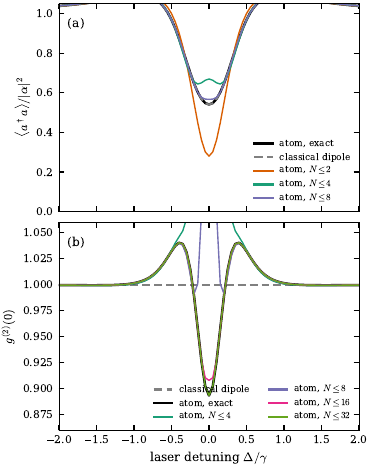

g2(0) on resonance: exact 0.8936, N<=32 0.8936, N<=16 0.9081
maximum of g2: 1.0405 at Delta/gamma = 0.40
max |n_atom/n_dipole - 1| = 4.3e-04;  max |g2(N<=32) - exact| = 1.1e-05


In [3]:
run("python3 make_figures.py atomcavity", "engines", timeout=1800)
paper_figure("engines/fig_atom_cavity.pdf", width=420)
n = J("engines", "numbers.json")["atomcav"]
print(f"g2(0) on resonance: exact {n['g2_res']:.4f}, N<=32 {n['g2_res_N32']:.4f}, N<=16 {n['g2_res_N16']:.4f}")
print(f"maximum of g2: {n['g2_max']:.4f} at Delta/gamma = {n['D_g2max']:.2f}")
print(f"max |n_atom/n_dipole - 1| = {n['maxdev_n_atom_cl']:.1e};  max |g2(N<=32) - exact| = {n['maxerr_g2_N32']:.1e}")